In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

We shall next study Gaussian process regression. The most canonical example of a Gaussian process is the Brownian Motion. Here is how it can be simulated. 

## Brownian Motion

$B_t$ is Brownian motion. The following algorithm simulates Brownian Motion on $[0, M]$ for some fixed $M$ (e.g.,  $M = 65$). 

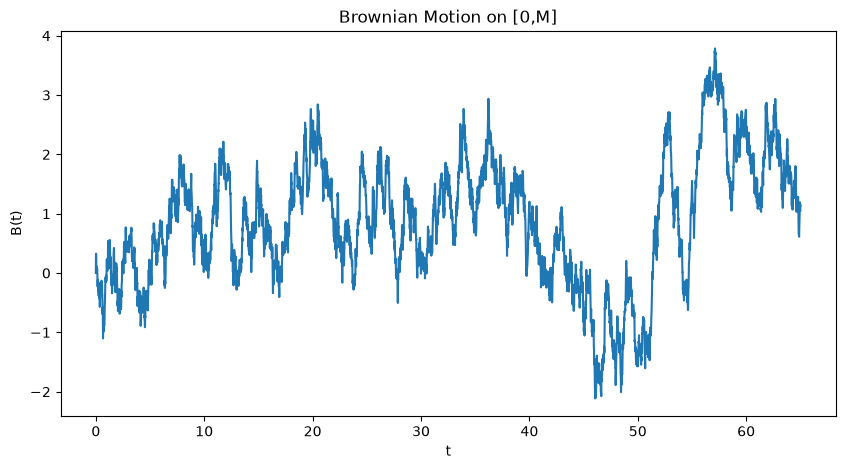

In [35]:
M = 65         # time horizon
N = 5000        # number of grid points
dt = M / N       # step size

t = np.linspace(0, M, N+1)

# generate increments
increments = np.sqrt(dt) * np.random.randn(N)

# Brownian path
B = np.zeros(N+1)
B[1:] = np.cumsum(increments)

plt.figure(figsize=(10, 5))
plt.plot(t, B)
plt.xlabel("t")
plt.ylabel("B(t)")
plt.title("Brownian Motion on [0,M]")
plt.show()


In the plot above, successive values are joined by straight lines. We can also plot by assuming that the value is constant in between successive values. This is done below.

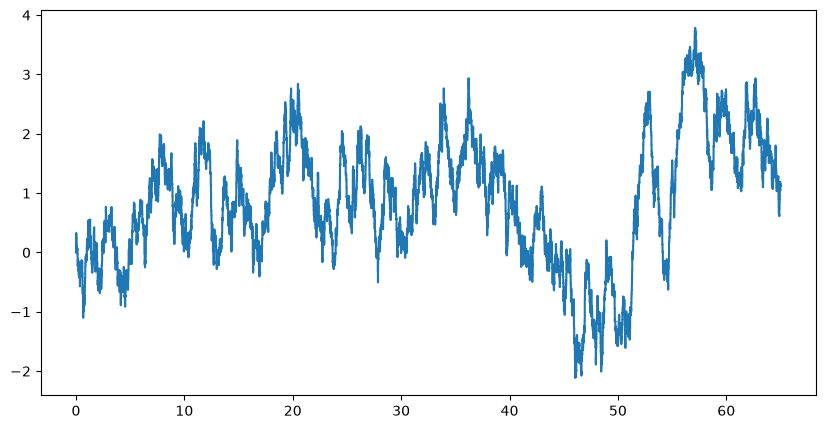

In [36]:
plt.figure(figsize=(10, 5))
plt.step(t, B, where="post")
plt.show()

When $N$ is large, we cannot spot any differences between the above two plots (the differences are much more apparent when $N$ is small). 

Note here that $t_i = i M/N$ for $i = 0, \dots, N$. In the second plot (plt.step) above, what we are plotting is: 
\begin{align*}
   \sum_{i=1}^N \alpha_i I\{t \geq i M/N \}
\end{align*}
where $\alpha_i := B(t_i) - B(t_{i-1}) \overset{\text{i.i.d}}{\sim} N(0, M/N)$. We are thus using the approximation: 
\begin{align*}
   B(t) \approx \sum_{i=1}^N \alpha_i I \{t \geq i M/N \}. 
\end{align*}
The implies the following ReLU approximation to Integrated Brownian Motion. 
\begin{align*}
   I(t) = \int_0^t B(s) ds \approx \sum_{i=1}^N \alpha_i \int_0^t I\{s \geq iM/N\} ds = \sum_{i=1}^N \alpha_i (t - iM/N)_+
\end{align*}


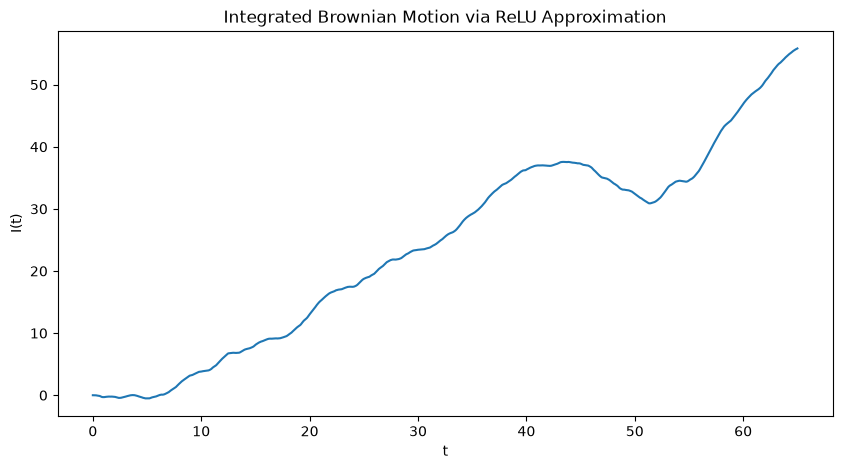

In [37]:
# Integrated Brownian Motion using the ReLU representation

knots = t[1:]  # iM/N, i = 1,...,N
alpha = increments

I_relu = np.zeros(N + 1)

for i in range(N):
    I_relu += alpha[i] * np.maximum(t - knots[i], 0)

plt.figure(figsize=(10, 5))
plt.plot(t, I_relu)
plt.xlabel("t")
plt.ylabel("I(t)")
plt.title("Integrated Brownian Motion via ReLU Approximation")
plt.show()

Now we will sample IBM curves with a linear drift. 

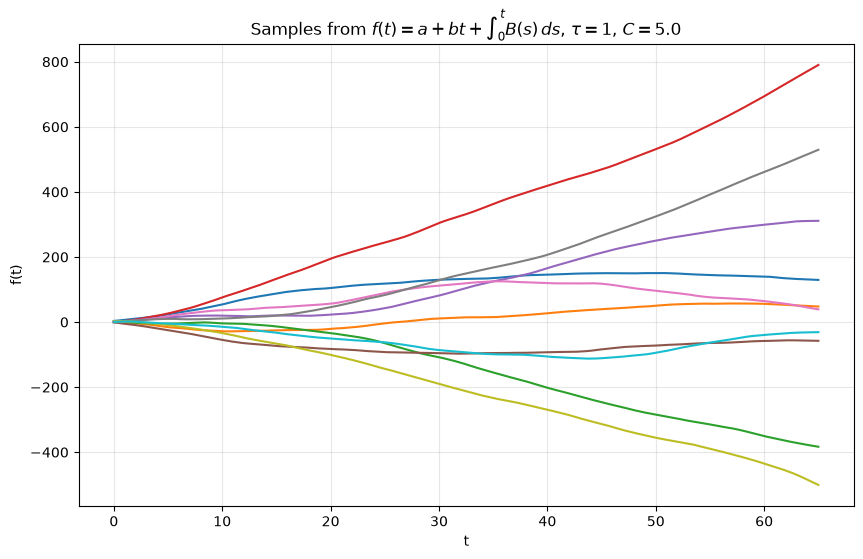

In [38]:
# Samples from f(t) = a + b t + Integrated Brownian Motion

tau = 1          # IBM scale
C = 5.0          # variance of intercept and slope
n_samples = 10

plt.figure(figsize=(10, 6))

for _ in range(n_samples):

    # Brownian increments
    increments = tau * np.sqrt(dt) * np.random.randn(N)

    # Brownian motion
    B = np.zeros(N + 1)
    B[1:] = np.cumsum(increments)

    # Integrated Brownian motion
    I = np.zeros(N + 1)
    I[1:] = np.cumsum(B[:-1] * dt)

    # Random linear part
    a = np.random.normal(0, np.sqrt(C))
    b = np.random.normal(0, np.sqrt(C))

    # Full sample path
    f = a + b * t + I

    plt.plot(t, f, lw=1.5)

plt.xlabel("t")
plt.ylabel("f(t)")
plt.title(fr"Samples from $f(t)=a+bt+\int_0^t B(s)\,ds$, $\tau={tau}$, $C={C}$")
plt.grid(alpha=0.3)
plt.show()

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Interpolation with Gaussian Processes

We are solving the following problem. Given the values of a function $f : [0, 1] \rightarrow \R$ at fixed points $0 \leq x_1 < \dots < x_n \leq 1$, what can we say about $f(x)$ for some $x$ that is distinct from $x_1, \dots, x_n$?

In [40]:
#Consider the following smooth function: 
def smoothfun(x):
    ans = np.sin(15*x) + 15*np.exp(-(x ** 3)/2) + 0.5*((x - 0.5) ** 2) + 5 * np.log(x + 0.1) + 7
    return ans

#Here is another example of a function: 
#def smoothfun(x):
#    ans = (np.sin(15*x) + 0.6*np.sin(60*x) + 0.4*np.sin(120*x) + 15*np.exp(-(x**3)/2) + 0.5*((x-0.5)**2) + 5*np.log(x+0.1) + 7)
#    return ans

#We observe this function at the following points: 
n = 5
xx = np.linspace(0, 1, n) #these are equally spaced points
xx = np.linspace(0.2, 0.8, n)
#xx = np.sort(np.random.rand(n)) #these are unequally spaced points

#these are the values of the function at the observed points, which we will treat as our data
truth = np.array([smoothfun(x) for x in xx])
y = truth

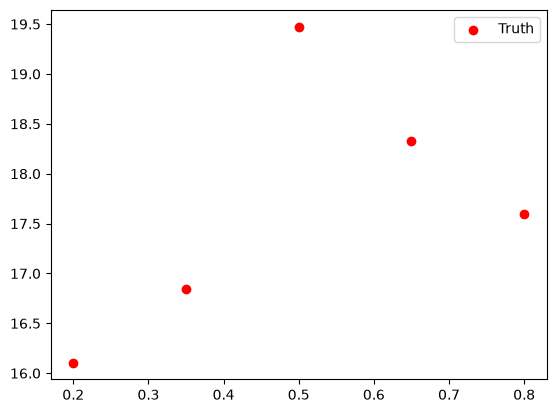

In [41]:
#Below we plot the scatter plot of the observed data
plt.scatter(xx, truth, label = 'Truth', color = 'red')
plt.legend()
plt.show()

## Interpolation using Brownian Motion

We will use the Brownian motion prior: $f(x) = \beta_0 + \tau B(x)$ with $\beta_0 \sim N(0, C)$ and $B(x)$ is Brownian motion. We will compute the posterior mean of $f(x)$ using the formula: $\mathbf{k}^TK^{-1} (f(x_1), \dots, f(x_n))^T$, where the kernel is given by $K(u, v) = C + \tau^2 \min(u, v)$. $K$ is the matrix whose $(i, j)$-th entry is $K(x_i, x_j)$, and $\mathbf{k}$  is the vector whose $i$-th element is $K(x, x_i)$. This calculation will require specification of $\tau$ and $C$ ($C$ can be large constant). The value of $\tau$ does not affect the posterior mean (as can be easily checked from the code below). We still choose a reasonable value of $\tau$ using the observation that: 
\begin{align*}
   f(x_i) - f(x_{i-1}) = \tau \left(B(x_i) - B(x_{i-1}) \right) \sim N(0, \tau^2 (x_i - x_{i-1}))
\end{align*}
This means that
\begin{align*}
    \mathbb{E} \frac{1}{n-1}\sum_{i=2}^n \left[ \frac{1}{x_{i} - x_{i-1}} \left( f(x_i) - f(x_{i-1}) \right)^2 \right] = \tau^2. 
\end{align*}
This gives a decent estimate of $\tau$ which we compute as follows. 

In [42]:
#crude estimate of tau
dx = np.diff(xx)
dy = np.diff(y)

tau2_hat = np.mean((dy**2) / dx)
tau_hat = np.sqrt(tau2_hat)

print(tau_hat)

3.943306705404783


With this value of $\tau$ and a large value of $C$, we compute the posterior mean of $f(x)$ as follows. We also compute the posterior variance (and the posterior standard deviation). Instead of computing these at a fixed value of $x$, we compute them over a grid of values of $x$. 

In [43]:
# hyperparameters
tau = tau_hat
C = 1000

# kernel
def kernel_BM(s,t):
    return C + tau**2 * min(s,t)

# covariance matrix
K = np.array([[kernel_BM(xi,xj) for xj in xx] for xi in xx])
Kinv = np.linalg.inv(K)

# grid for prediction
grid = np.linspace(0,1,200)

post_mean_bm = np.zeros(len(grid))
post_var_bm = np.zeros(len(grid))

for i,x in enumerate(grid):

    kstar = np.array([kernel_BM(x,xi) for xi in xx])
    kxx = kernel_BM(x,x)

    post_mean_bm[i] = kstar @ Kinv @ truth
    post_var_bm[i] = kxx - kstar @ Kinv @ kstar

post_sd_bm = np.sqrt(post_var_bm)

Below we plot the posterior means of the grid points (as well as twice the posterior standard deviations). The posterior standard deviations give an idea of the uncertainty present in the mean estimates. 

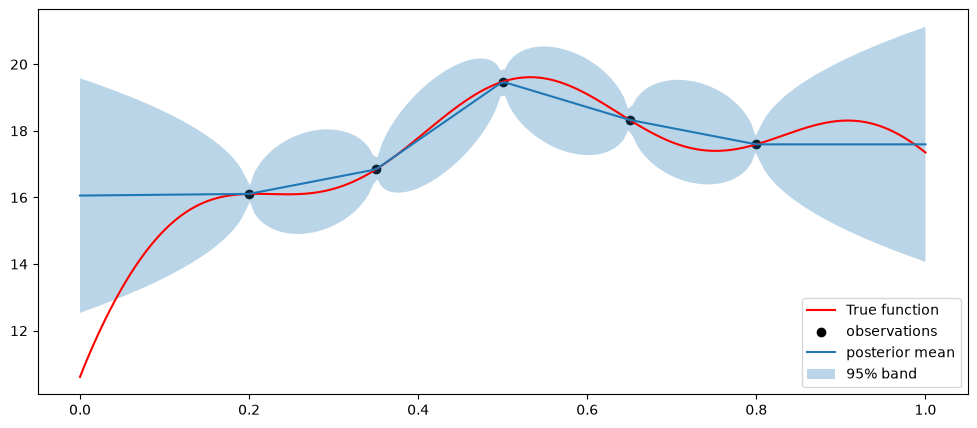

In [44]:
truth_grid = np.array([smoothfun(x) for x in grid])
plt.figure(figsize=(12,5))
plt.plot(grid, truth_grid, label="True function", color="red")
plt.scatter(xx,y,color="black",label="observations")

plt.plot(grid, post_mean_bm, label="posterior mean")

plt.fill_between(grid,
                 post_mean_bm-2*post_sd_bm,
                 post_mean_bm+2*post_sd_bm,
                 alpha=0.3,
                 label="95% band")

plt.legend()
plt.show()

Below we only plot the posterior mean. 

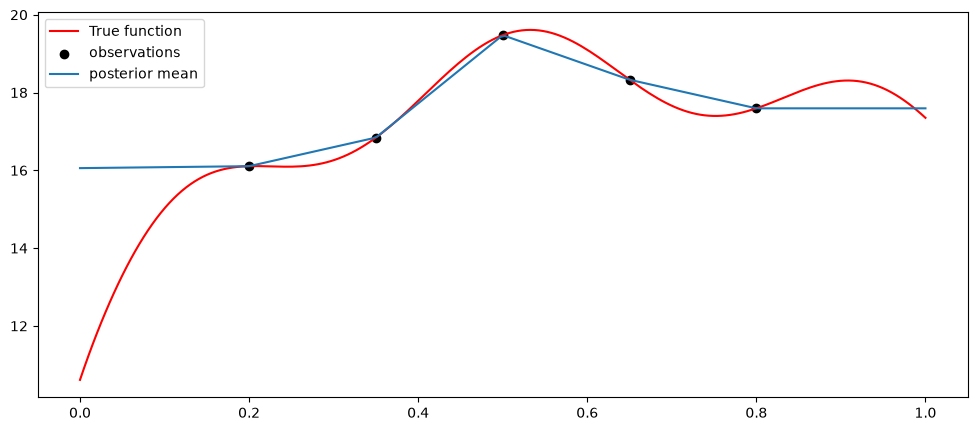

In [45]:
#Only plotting the posterior mean: 
plt.figure(figsize=(12,5))
plt.plot(grid, truth_grid, label="True function", color="red")
plt.scatter(xx,y,color="black",label="observations")
plt.plot(grid, post_mean_bm, label="posterior mean")
plt.legend()
plt.show()

Clearly the posterior mean linearly interpolates between the data. Go back and changes $x_1, \dots, x_n$ so they are random points in $[0, 1]$ which allows us to see that estimates beyond $[x_1, x_n]$ are constant. 

## Interpolation using Integrated Brownian Motion

Now we use the prior $f(x) = \beta_0 + \beta_1 x + \tau I(x)$ where $I(x)$ is integrated Brownian motion. The code for computing the posterior mean of $f(x)$ is same as below; the only change is in the formula for $K(u, v)$. 

In [46]:
# hyperparameters
tau = 100.0
C = 100000.0

# covariance of integrated Brownian motion
def kernel_IBM(s, t):
    m = min(s, t)
    M = max(s, t)
    return (m**2) * (3*M - m) / 6.0

# full kernel for f(x) = beta0 + beta1 x + tau I(x)
def kernel_f(s, t):
    return C + C*s*t + tau**2 * kernel_IBM(s, t)

# covariance matrix
K = np.array([[kernel_f(xi, xj) for xj in xx] for xi in xx])

# tiny jitter just for numerical stability
K = K + 1e-10 * np.eye(len(xx))

Kinv = np.linalg.inv(K)

# grid for prediction
grid = np.linspace(0, 1, 200)

post_mean_ibm = np.zeros(len(grid))
post_var_ibm = np.zeros(len(grid))

for i, x in enumerate(grid):
    kstar = np.array([kernel_f(x, xi) for xi in xx])
    kxx = kernel_f(x, x)

    post_mean_ibm[i] = kstar @ Kinv @ truth
    post_var_ibm[i] = kxx - kstar @ Kinv @ kstar

# guard against tiny negative values from floating point error
post_var_ibm = np.maximum(post_var_ibm, 0)
post_sd_ibm = np.sqrt(post_var_ibm)

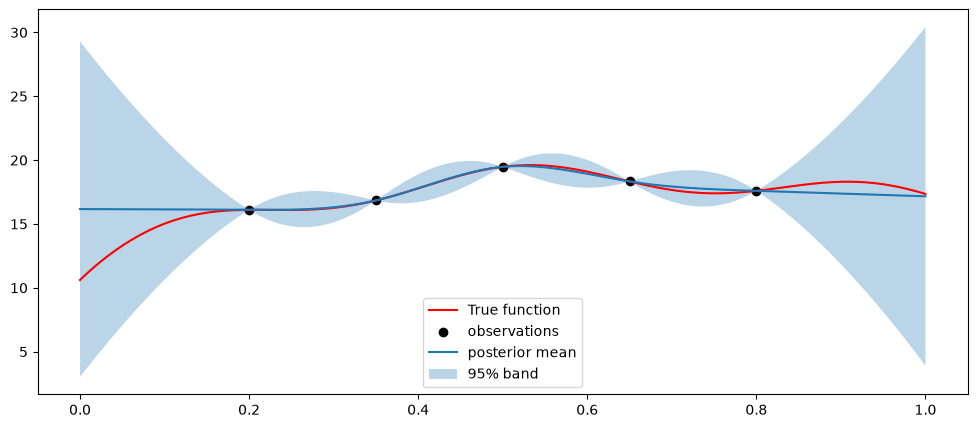

In [47]:
truth_grid = np.array([smoothfun(x) for x in grid])
plt.figure(figsize=(12,5))
plt.plot(grid, truth_grid, label="True function", color="red")
plt.scatter(xx,y,color="black",label="observations")

plt.plot(grid, post_mean_ibm, label="posterior mean")

plt.fill_between(grid,
                 post_mean_ibm-2*post_sd_ibm,
                 post_mean_ibm+2*post_sd_ibm,
                 alpha=0.3,
                 label="95% band")

plt.legend()
plt.show()

It is interesting that the posterior variance is narrower between the observed points and becomes wider as we go away from the observations and close to the boundary. 

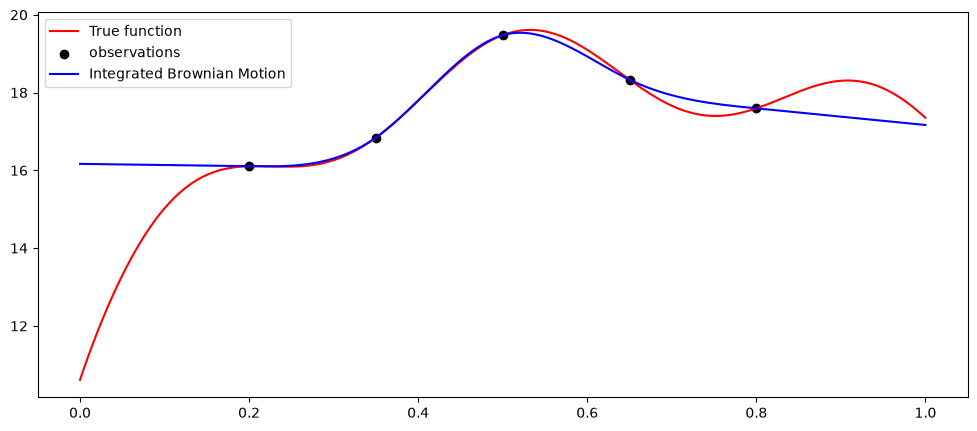

In [48]:
#Only plotting the posterior mean: 
plt.figure(figsize=(12,5))
plt.plot(grid, truth_grid, label="True function", color="red")
plt.scatter(xx,y,color="black",label="observations")
#plt.plot(grid, post_mean_bm, label = 'Brownian Motion', color = 'black')
plt.plot(grid, post_mean_ibm, label = 'Integrated Brownian Motion', color = 'blue')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Gaussian Process Regression

Consider again the wages dataset that we have been using for the past few lectures. This simple dataset, which comes from the introductory statistics textbook "Statistical Sleuth" by Ramsey and Schafer,  contains weekly wages in 1987 for a sample of 25437 males between the ages of 18 and 70 who worked full-time along with their years of education, years of experience, indicator variable for whether they worked near a city, and a code for the region in the US where they worked.

In [49]:
#Load the dataset wagedata.csv
dt = pd.read_csv("wagedata.csv")
print(dt.head(10))
print(dt.shape)

      Region   MetropolitanStatus  Exper  Educ  WeeklyEarnings
0      South  NotMetropolitanArea      8    12          859.71
1    Midwest     MetropolitanArea     30    12          786.73
2       West     MetropolitanArea     31    14         1424.50
3       West     MetropolitanArea     17    16          959.16
4       West     MetropolitanArea      6    12          154.32
5    Midwest     MetropolitanArea     24    17          282.19
6  Northeast     MetropolitanArea     14    12          444.44
7  Northeast     MetropolitanArea     28    12          451.09
8      South     MetropolitanArea     40    12          490.27
9      South     MetropolitanArea      7    16          493.83
(25437, 5)


We want to fit a regression model with logarithm of weekly earnings as the response variable:
\begin{align*}
   y = \log \left( \text{weekly earnings} \right)
\end{align*}
and years of experience as the covariate: 
\begin{align*}
   x = \text{Exper} = \text{Years of Experience}.
\end{align*}
The following is the scatter plot between $y$ and $x$. 

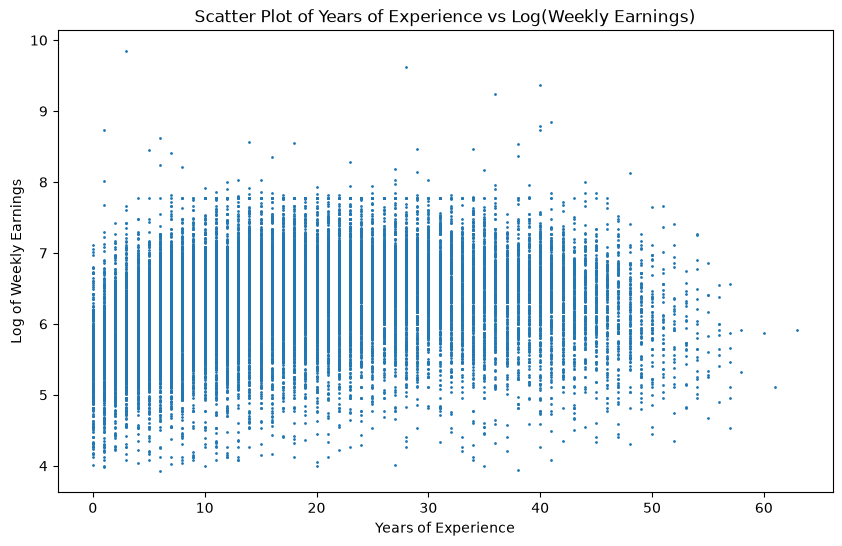

In [50]:
import numpy as np
y = np.log(dt['WeeklyEarnings'])
x = dt['Exper'].to_numpy()
import matplotlib.pyplot as plt
plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 1)
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('Scatter Plot of Years of Experience vs Log(Weekly Earnings)')
plt.show()

In [52]:
#Repeating the analysis on a smaller dataset: 
n = 500
random_seed = 42
dt_small = dt.sample(n = 500, random_state = random_seed)
#dt_small = dt #this is to switch back to the full dataset
y = np.log(dt_small['WeeklyEarnings'])
x = dt_small['Exper'].to_numpy()
n = len(y)


We want to consider the model: 
\begin{align*}
   y = f(x) + \epsilon 
\end{align*}
where $\epsilon \sim N(0, \sigma^2)$. 

## Integrated Brownian Motion Prior

For $f$, we want to use the integrated Brownian motion plus a linear term prior: 
\begin{align*}
   f(x) = \beta_0 + \beta_1 x + \tau I(x) 
\end{align*}
where $I(x)$ is integrated Brownian motion and $\beta_0, \beta_1$ are $N(0, C)$ for a large $C$. 

This is a Gaussian Process model with mean function zero and covariance kernel: 
\begin{align*}
   K(u, v) = C(1 + uv) + \tau^2 \frac{(\min(u, v))^2}{6} \left(3 \max(u, v) - \min(u, v)\right).  
\end{align*}

If $\gamma := \tau/\sigma$ is fixed, then the posterior mean of $f$ at a test point $u$ is given by: 
\begin{align*}
   \hat{f}(u) := (1, u) \left(X^T A_{\gamma}^{-1} X \right)^{-1} X^T A_{\gamma}^{-1} y + \gamma^2 k_I(u)^T \left(A_{\gamma}^{-1} - A_{\gamma}^{-1} X (X^T A_{\gamma}^{-1} X)^{-1} X^T A_{\gamma}^{-1} \right) y
\end{align*}
where $X$ is the $n \times 2$ design matrix of the usual linear regression (with columns of ones and $x_1, \dots, x_n$), 
\begin{align*}
   k_I(u) := (k_I(u, x_1), \dots, k_I(u, x_n))^T ~~~ \text{and} ~~~ K_I := (K_I(x_i, x_j))_{n \times n},
\end{align*}
and
\begin{align*}
    A_{\gamma} = I_{n \times n} + \gamma^2 K_I. 
\end{align*}
Note that the posterior mean only depends on $\gamma = \tau/\sigma$ and not on $\tau$ and $\sigma$ individually. 

The following code computes the posterior mean of $f(u)$ given a fixed value of $\gamma$. In the code, we are using the notation: 
\begin{align*}
P = A_{\gamma}^{-1} - A_{\gamma}^{-1} X (X^T A_{\gamma}^{-1} X)^{-1} X^T A_{\gamma}^{-1}.
\end{align*}
and
\begin{align*}
  \alpha = \left(X^T A_{\gamma}^{-1} X \right)^{-1} X^T A_{\gamma}^{-1} y. 
\end{align*}

In [65]:
gamma = 0.027 #some arbitrary value
#gamma = 0.1
#gamma = .0001
#gamma = 2
#gamma = 10
X = np.column_stack((np.ones(n), x)) #usual X matrix for linear regression

def K_I(u, v):
    minuv = min(u, v)
    maxuv = max(u, v)
    return (minuv**2 / 6.0) * (3*maxuv - minuv)

K_ibm = np.array([[K_I(xi, xj) for xj in x] for xi in x])

# grid
M = np.max(x)
grid_f = np.linspace(0, M, 100) #number of points u where the posterior mean is calculated
kvec  = np.array([[K_I(u, xi) for xi in x] for u in grid_f])

# A_gamma
A_gamma = np.eye(n) + gamma**2 * K_ibm
A_gamma_inv = np.linalg.inv(A_gamma)

#the X^T A_gamma^-1 X and its inverse
XtAinvX = X.T @ A_gamma_inv @ X
XtAinvX_inv = np.linalg.inv(XtAinvX)

# the matrix P (defined above)
P = A_gamma_inv - A_gamma_inv @ X @ XtAinvX_inv @ X.T @ A_gamma_inv

# Offset term:
alpha = XtAinvX_inv  @ X.T @ A_gamma_inv @ y

# all the vectors (1, u) stacked together for all u in grid_f
H = np.column_stack((np.ones(len(grid_f)), grid_f))

# posterior mean
post_mean = H @ alpha + gamma**2 * kvec @ (P @ y)

The biggest computational bottleneck in the code above involves the inversion of the $n \times n$ matrix $A_{\gamma}$. When $n$ is large, the code can be quite slow. For example, try the code on the full dataset with $n \approx 25000$. 

Let us plot the posterior mean estimates on the data. 

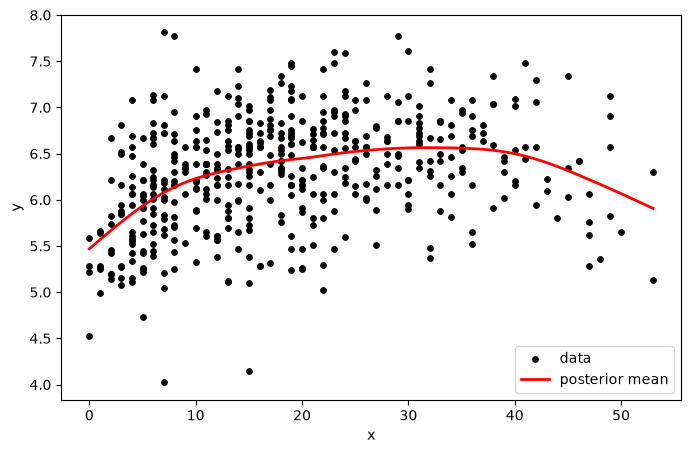

In [66]:
plt.figure(figsize=(8,5))
# data
plt.scatter(x, y, color="black", s=15, label="data")
# posterior mean curve
plt.plot(grid_f, post_mean, color="red", linewidth=2, label="posterior mean")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

The above seems a good fit to the data, capturing that the average log weekly income first increases and then decreases with experience. Go back and change gamma and see the resulting fit.  

Next we learn the values of $\gamma$ and $\sigma$. The marginal posterior of $\gamma$ is given by: 
\begin{align*}
   \text{posterior of } \gamma \propto \frac{p(\gamma) |A_{\gamma}|^{-1/2} |X^T A_{\gamma}^{-1} X|^{-1/2}}{\left(y^T \left[A_{\gamma}^{-1} - A_{\gamma}^{-1} X (X^T A_{\gamma}^{-1} X)^{-1} X^T A_{\gamma}^{-1} \right] y \right)^{(n/2)- 1}}.   
\end{align*}
where $p(\gamma)$ is the prior for $\gamma$ which we take:
\begin{align*}
    p(\gamma) \propto \frac{I\{\gamma_{\text{low}} \leq \gamma \leq \gamma_{\text{high}}\}}{\gamma}
\end{align*}
for two values $\gamma_{\text{low}}$ and $\gamma_{\text{high}}$ (roughly, $\gamma_{\text{low}}$ will be taken such that the posterior mean of $f$ gives the least squares line, and $\gamma_{\text{high}}$ will be taken such that the posterior mean of $f$ gives an overfitted curve). 

In [63]:
gamma_low = 0.0001
gamma_high = 10
grid_size = 2000
gamma_gr = np.logspace(np.log10(gamma_low), np.log10(gamma_high), grid_size)
logpost_gamma = np.zeros(len(gamma_gr))
Svals = np.zeros(len(gamma_gr))

for i in range(len(gamma_gr)):
    gamma = gamma_gr[i]
    A_gamma = np.eye(n) + gamma ** 2 * K_ibm
    A_gamma_inv = np.linalg.inv(A_gamma)
    XtAinvX = X.T @ A_gamma_inv @ X
    XtAinvX_inv = np.linalg.inv(XtAinvX)
    P = A_gamma_inv - A_gamma_inv @ X @ XtAinvX_inv @ X.T @ A_gamma_inv
    S = y.T @ P @ y
    Svals[i] = S
    sign1, logdetA = np.linalg.slogdet(A_gamma)
    sign2, logdetXtAinvX = np.linalg.slogdet(XtAinvX)
    logpost_gamma[i] = -np.log(gamma)-0.5*logdetA-0.5*logdetXtAinvX-(n/2 - 1)*np.log(S)
    #logpost_gamma[i] = -0.5*logdetA-0.5*logdetXtAinvX-(n/2 - 1)*np.log(S) #if we replace the 1/gamma prior with a flat prior, this will be the posterior of gamma

In [64]:
post_gamma = np.exp(logpost_gamma - np.max(logpost_gamma))
# correct for log grid spacing
post_gamma = post_gamma * gamma_gr
#normalization: 
post_gamma = post_gamma / np.sum(post_gamma)
postmean_gamma = np.sum(gamma_gr * post_gamma)
print(postmean_gamma)
print(1/(postmean_gamma**2))  # lambda = 1/gamma^2

0.027786012231468663
1295.231968187476


This posterior mean of $\gamma$ provides an automatic choice that can be used downstream to calculate the posterior mean of $f$.



In the previous lecture, we worked with the model:
\begin{align*}
   f(x) = \beta_0 + \beta_1 x + \beta_2 (x - 1)_+ + \dots + \beta_m(x - (m-1))_+
\end{align*}
where $m = 63$, along with
\begin{align*}
   \beta_0, \beta_1 \sim N(0, C) ~~ \text{ and } ~~ \beta_2, \dots, \beta_m \sim N(0, \tau^2). 
\end{align*}
We argued previously that this can be seen as a discretized version of the prior: 
\begin{align*}
    f(x) = \beta_0 + \beta_1 x + \tau I(x)
\end{align*}
where $I(x)$ is integrated Brownian motion, and $\beta_0, \beta_1 \sim N(0, C)$. 

Let us compare the resulting estimates of $f$ using the discretized prior, as well as using the IBM prior. 

In [ ]:
y = np.log(dt_small['WeeklyEarnings'])
x = dt_small['Exper']
n = len(y)
X_all_knots = sm.add_constant(x) #adding intercept
for knot in range(1, 63):
    X_all_knots[f'knot_{knot}'] = np.maximum(x - knot, 0)


In [ ]:
X = X_all_knots.to_numpy()
print(X.shape)
m = 63 #the parameters are b_0, \dots, b_m

As for the IBM prior, we first need to estimate $\gamma$ (note that $\gamma = \tau/\sigma$). 

In [ ]:
gamma_low = 0.0001
gamma_high = 10
gamma_gr = np.logspace(np.log10(gamma_low), np.log10(gamma_high), 2000)
logpost_gamma = np.zeros(len(gamma_gr))

for i in range(len(gamma_gr)):
    gamma = gamma_gr[i]
    J_by_gammasq = np.diag(np.concatenate([[0, 0], np.repeat(gamma**(-2), m-1)])) 
    Mat =  X.T @ X + J_by_gammasq
    Matinv = np.linalg.inv(Mat)
    sgn, logcovdet = np.linalg.slogdet(Matinv)
    logpost_gamma[i] =(-m)*np.log(gamma) + 0.5 * logcovdet - (n/2 - 1)*np.log(y.T @ y - y.T @ X @ Matinv @ X.T @ y)


In [ ]:
post_gamma  = np.exp(logpost_gamma - np.max(logpost_gamma))
# correct for log grid spacing
post_gamma = post_gamma * gamma_gr
#normalization: 
post_gamma = post_gamma/np.sum(post_gamma)
postmean_gamma = np.sum(gamma_gr * post_gamma)
print(postmean_gamma)
print(1/(postmean_gamma ** 2)) #this is lambda = 1/gamma^2

The posterior mean of $\gamma$ in this discretized model is basically the same as that in the continuous IBM model. 

In [ ]:
gamma = 0.0278
J_by_gammasq = np.diag(np.concatenate([[0, 0], np.repeat(gamma**(-2), m-1)])) 
XTX = np.dot(X.T, X)
Mat =  XTX + J_by_gammasq
Matinv = np.linalg.inv(Mat)
XTy = np.dot(X.T, y)
beta_post_mean = Matinv @ XTy

In [ ]:
#calculating the fitted values for a grid of x-values:
X_range = pd.DataFrame({'const': 1, 'x': grid_f})
kmax = m - 1
for knot in range(1, (1 + kmax)):
    X_range[f'knot_{knot}'] = np.maximum(grid_f - knot, 0)

fitted_model_postmean_fullmodel = X_range.values @ beta_post_mean

In [ ]:
plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 5)
plt.plot(grid_f,fitted_model_postmean_fullmodel, color = 'red', label = 'Regression Estimate with the Discretized Prior')
plt.plot(grid_f, post_mean, color = 'blue', label = 'Regression Estimate with the Integrated Brownian Motion')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('Two regression estimates of y on x')
plt.legend()
plt.show()

The two posterior mean estimates are very nearly the same. However the latter code (i.e., with the discretized prior) is much faster compared to the code with the Integrated Brownian Motion. This is because, for the discretized linear model, there is no $n \times n$ inversion that needs to be done. Rather we need to invert a 64 times 64 matrix in the discretized model. 

Aesthetically, the integration Brownian motion prior is very nice because it does not involve any ad-hoc discretization. However, it is more expensive computationally. Some linear algebra tricks (such as using the Cholesky decomposition) can be used to make the code faster but we will not go into those details. 

The main takeaway is that the bayesian machinery tells us how to choose the hyperparameters tau and sigma automatically. 